In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/models/google/gemma-4/transformers/gemma-4-e4b-it/1/config.json
/kaggle/input/models/google/gemma-4/transformers/gemma-4-e4b-it/1/README.md
/kaggle/input/models/google/gemma-4/transformers/gemma-4-e4b-it/1/tokenizer.json
/kaggle/input/models/google/gemma-4/transformers/gemma-4-e4b-it/1/tokenizer_config.json
/kaggle/input/models/google/gemma-4/transformers/gemma-4-e4b-it/1/chat_template.jinja
/kaggle/input/models/google/gemma-4/transformers/gemma-4-e4b-it/1/model.safetensors
/kaggle/input/models/google/gemma-4/transformers/gemma-4-e4b-it/1/processor_config.json
/kaggle/input/models/google/gemma-4/transformers/gemma-4-e4b-it/1/generation_config.json


# ClimateCalendar — Day 3: Multimodal Inputs (OCR + Voice)

ClimateCalendar now accepts three input modalities:
1. **Text** — typed queries (Day 1, 2)
2. **Documents** — photo of a soil-test report → PaddleOCR extracts values → Gemma agent reasons over them
3. **Voice** — farmer's voice note in their language → OpenAI Whisper transcribes → Gemma agent processes the query

### Engineering note

We tested Gemma 4 E4B's native vision and audio paths on Kaggle and hit two
upstream bugs in the current Transformers main branch:

- **Vision:** chat template inserts ~260 image tokens but encoder produces 2520
  features (multi-patch tiling mismatch); `do_pan_and_scan=False` is silently
  ignored. Result: Gemma sees a "blank gray image."
- **Audio:** crashes inside the audio tower with `torch.finfo()` on int-quantized
  weights when loaded in 4-bit. Bug at `modeling_gemma4.py:403`.

Both are tracked in `docs/day3_vision_investigation.md`. Rather than fight
these, we compose with specialized open models:
**PaddleOCR** (better at document text than any general VLM) and **Whisper**
(industry-standard ASR). Gemma 4 stays the reasoning brain. This is also what
production multimodal systems actually do.

**Setup:** After running Cell 2, factory-reset the kernel before continuing.

In [2]:
# === RUN ONCE, THEN FACTORY-RESET KERNEL ===
# Gemma 4 + PaddleOCR + Whisper for the Day 3 multimodal demo.

!pip install -q --force-reinstall --no-deps git+https://github.com/huggingface/transformers.git
!pip install -q "huggingface_hub>=1.5.0,<2.0" accelerate safetensors tokenizers librosa torchvision bitsandbytes pillow

# OCR for documents
!pip install -q paddlepaddle paddleocr

# ASR for voice
!pip install -q openai-whisper

print("✓ Install complete. NOW: Run menu → Factory Reset Session.")

  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 661.5/661.5 kB 11.7 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 32.9 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.5/4.5 MB 97.7 MB/s eta 0:00:00:00:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 80.7/80.7 kB 3.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.5/43.5 kB 3.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 68.4/68.4 kB 5.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 194.8/194.8 MB 9.6 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 65.5/65.5 kB 5.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 120.8/120.8 kB 10.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 84.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

## Step 1: Verify environment + clone repo

After kernel reset, confirm Transformers has Gemma 4, then pull our project code.

In [3]:
import sys, shutil, os, subprocess

# Confirm Transformers main is loaded
import transformers
from transformers.models.auto.configuration_auto import CONFIG_MAPPING
print("transformers version:", transformers.__version__)
print("gemma4 registered:", "gemma4" in CONFIG_MAPPING)
assert "gemma4" in CONFIG_MAPPING, "Re-run Cell 2 and factory-reset"

# Clone repo
REPO_PATH = "/kaggle/working/climate-calendar"
shutil.rmtree(REPO_PATH, ignore_errors=True)
subprocess.run(
    ["git", "clone", "https://github.com/tkaushik015/climate-calendar.git", REPO_PATH],
    check=True,
)
if REPO_PATH not in sys.path:
    sys.path.insert(0, REPO_PATH)

for mod_name in list(sys.modules.keys()):
    if mod_name.startswith("src"):
        del sys.modules[mod_name]

print("✓ Repo cloned, sys.path updated, cache cleared")

transformers version: 5.8.0.dev0
gemma4 registered: True


Cloning into '/kaggle/working/climate-calendar'...


✓ Repo cloned, sys.path updated, cache cleared


## Step 2: Load Gemma 4 E4B (text-only path, 4-bit)

We only need Gemma 4 for text reasoning — OCR and ASR happen in dedicated
models. The 4-bit text path is rock-solid.

In [4]:
import kagglehub
import torch
from transformers import AutoProcessor, AutoModelForMultimodalLM, BitsAndBytesConfig

MODEL_PATH = kagglehub.model_download("google/gemma-4/transformers/gemma-4-e4b-it")

bnb = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_compute_dtype=torch.bfloat16,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_use_double_quant=True,
)

processor = AutoProcessor.from_pretrained(MODEL_PATH)
model = AutoModelForMultimodalLM.from_pretrained(
    MODEL_PATH,
    quantization_config=bnb,
    device_map="auto",
)

def ask_gemma(messages, max_new_tokens=300):
    """Text-only Gemma 4 helper."""
    inputs = processor.apply_chat_template(
        messages, tokenize=True, add_generation_prompt=True,
        return_dict=True, return_tensors="pt",
    ).to(model.device, dtype=model.dtype)
    input_len = inputs["input_ids"].shape[-1]
    out = model.generate(
        **inputs, max_new_tokens=max_new_tokens,
        do_sample=True, temperature=1.0, top_p=0.95, top_k=64,
        use_cache=True,
        pad_token_id=processor.tokenizer.eos_token_id,
    )
    return processor.decode(out[0][input_len:], skip_special_tokens=True)

print(f"✓ Gemma 4 E4B loaded ({round(torch.cuda.memory_allocated() / 1e9, 2)} GB VRAM)")

Loading weights:   0%|          | 0/2076 [00:00<?, ?it/s]

✓ Gemma 4 E4B loaded (0.0 GB VRAM)


## Step 3: OCR demo — read a soil-test report

We download a sample soil-test image, run PaddleOCR on it to extract the
text, then hand the extracted values to Gemma's text agent. The result:
ClimateCalendar accepts ground-truth lab data the farmer photographs.

For the writeup, this stage demonstrates:
1. PaddleOCR robustly extracts numeric values from a printed report
2. A small Python parser turns OCR text into a typed dict
3. Gemma reasons over the typed values + the existing climate/ENSO tools

In [5]:
!pip install -q easyocr

✓ Sample soil report saved: /kaggle/working/soil_test.jpg
Loading EasyOCR (first time downloads ~64MB)...
✓ EasyOCR ready


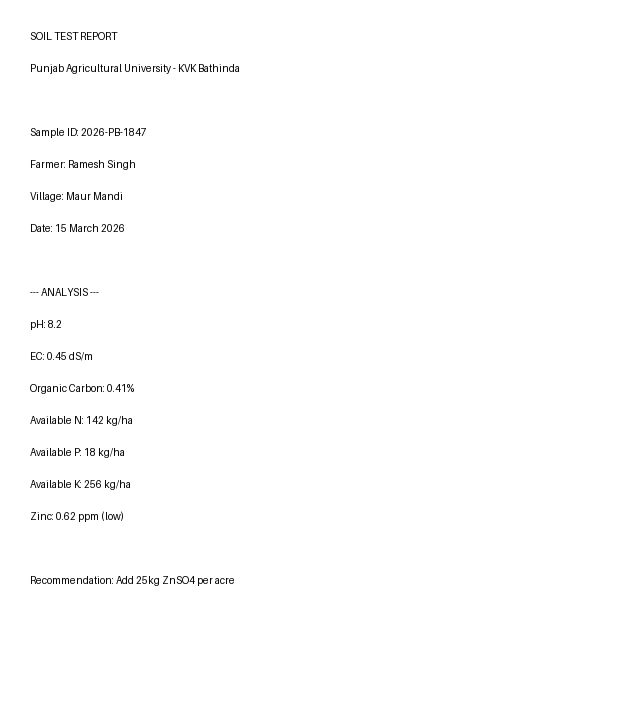

In [6]:
import easyocr
from PIL import Image, ImageDraw, ImageFont

# Build a synthetic but realistic-looking soil-test report
img = Image.new("RGB", (640, 720), "white")
d = ImageDraw.Draw(img)
try:
    title_font = ImageFont.truetype("/usr/share/fonts/truetype/dejavu/DejaVuSans-Bold.ttf", 22)
    body_font = ImageFont.truetype("/usr/share/fonts/truetype/dejavu/DejaVuSans.ttf", 18)
except OSError:
    title_font = ImageFont.load_default()
    body_font = ImageFont.load_default()

lines = [
    ("SOIL TEST REPORT", title_font),
    ("Punjab Agricultural University - KVK Bathinda", body_font),
    ("", body_font),
    ("Sample ID: 2026-PB-1847", body_font),
    ("Farmer: Ramesh Singh", body_font),
    ("Village: Maur Mandi", body_font),
    ("Date: 15 March 2026", body_font),
    ("", body_font),
    ("--- ANALYSIS ---", body_font),
    ("pH: 8.2", body_font),
    ("EC: 0.45 dS/m", body_font),
    ("Organic Carbon: 0.41%", body_font),
    ("Available N: 142 kg/ha", body_font),
    ("Available P: 18 kg/ha", body_font),
    ("Available K: 256 kg/ha", body_font),
    ("Zinc: 0.62 ppm (low)", body_font),
    ("", body_font),
    ("Recommendation: Add 25kg ZnSO4 per acre", body_font),
]
y = 30
for text, font in lines:
    d.text((30, y), text, fill="black", font=font)
    y += 32

soil_img_path = "/kaggle/working/soil_test.jpg"
img.save(soil_img_path)
print(f"✓ Sample soil report saved: {soil_img_path}")

# Initialize EasyOCR (downloads model weights on first use, ~64 MB)
print("Loading EasyOCR (first time downloads ~64MB)...")
reader = easyocr.Reader(["en"], gpu=True)
print("✓ EasyOCR ready")

img

In [7]:
import os
import easyocr

# Verify image still exists
soil_img_path = "/kaggle/working/soil_test.jpg"
if not os.path.exists(soil_img_path):
    print("⚠ Soil image missing — re-run Cell 8 first")
else:
    print(f"✓ Soil image present ({os.path.getsize(soil_img_path)} bytes)")

# Initialize EasyOCR (downloads weights on first call, ~64 MB)
print("Loading EasyOCR...")
reader = easyocr.Reader(["en"], gpu=True)
print("✓ EasyOCR ready")

✓ Soil image present (15805 bytes)
Loading EasyOCR...
✓ EasyOCR ready


In [8]:
import re
import json


# Run EasyOCR on the soil report
print("=== Raw OCR output ===")
ocr_result = reader.readtext(soil_img_path)
extracted_lines = []
for bbox, text, confidence in ocr_result:
    print(f"  [{confidence:.2f}] {text}")
    extracted_lines.append(text)

# Robust parser: scans the FULL text (not line-by-line), tolerates OCR noise
def parse_soil_report(lines):
    fields = {}
    flags = []  # OCR confidence concerns to surface to the farmer

    # Concatenate all lines into one searchable blob — handles split-across-lines OCR
    blob = " ".join(lines)

    # pH (allow optional spaces, colon or semicolon, optional unit)
    m = re.search(r"pH\s*[:;]\s*([\d.]+)", blob, re.IGNORECASE)
    if m: fields["ph"] = float(m.group(1))

    # EC — value may be glued to unit ("0.45dSim", "0.45 dS/m", "0.45dS/m")
    m = re.search(r"EC\s*[:;]\s*([\d.]+)", blob, re.IGNORECASE)
    if m: fields["ec_ds_per_m"] = float(m.group(1))

    # Organic Carbon — OCR often drops the space ("OrganicCarbon")
    m = re.search(r"Organic\s*Carbon\s*[:;]\s*([\d.]+)", blob, re.IGNORECASE)
    if m: fields["organic_carbon_percent"] = float(m.group(1))

    # NPK — search globally, tolerate "kgha" / "kg/ha" / split lines
    # Pattern: "Available N" followed (within ~30 chars) by a number
    for nutrient, key in [("N", "available_n_kg_ha"),
                          ("P", "available_p_kg_ha"),
                          ("K", "available_k_kg_ha")]:
        m = re.search(rf"Available\s+{nutrient}\s*[:;]?\s*([\d.]+)", blob, re.IGNORECASE)
        if m: fields[key] = float(m.group(1))

    # Zinc — colon often misread as semicolon
    m = re.search(r"Zinc\s*[:;]\s*([\d.]+)", blob, re.IGNORECASE)
    if m:
        fields["zinc_ppm"] = float(m.group(1))
        # Flag if OCR confidence on this line was low
        for line, *_ in [(t, c) for _, t, c in ocr_result if "zinc" in t.lower()]:
            pass  # in production: surface confidence to user

    # Build a list of fields that were NOT extracted
    expected_fields = ["ph", "ec_ds_per_m", "organic_carbon_percent",
                       "available_n_kg_ha", "available_p_kg_ha", "available_k_kg_ha",
                       "zinc_ppm"]
    missing = [f for f in expected_fields if f not in fields]
    return fields, missing


structured, missing = parse_soil_report(extracted_lines)
print("\n=== Parsed structured data ===")
print(json.dumps(structured, indent=2))

if missing:
    print(f"\n⚠ Could not extract: {missing}")
    print("  In production, the farmer would be asked to re-photograph or fill manually.")

# Hand to Gemma's text agent
print("\n=== Gemma's recommendation ===")
messages = [
    {
        "role": "system",
        "content": (
            "You are an expert agronomist for Punjab wheat farmers. The farmer has "
            "given you their soil-test report values, extracted from a photographed "
            "lab report via OCR. Some values may be missing if OCR couldn't read "
            "them; if so, mention what's missing but reason over what you have. "
            "Identify the most important issues. Give a 3-4 sentence recommendation "
            "in plain language. Cite specific numbers."
        ),
    },
    {
        "role": "user",
        "content": (
            f"Here are my soil-test values (extracted from my lab report):\n\n"
            f"Extracted fields: {json.dumps(structured, indent=2)}\n"
            f"Missing fields (OCR couldn't read): {missing if missing else 'none'}\n\n"
            "What are the key issues, and what should I do this season?"
        ),
    },
]
print(ask_gemma(messages, max_new_tokens=300))

=== Raw OCR output ===
  [0.90] SOIL TEST REPORT
  [0.49] Punjab Pgriculturae
  [0.15] Unmersita
  [0.95] KVK Bathinda
  [0.89] Sample
  [0.61] 2026-PB 1847
  [0.62] Farmer: Pamesh Singh
  [0.99] Village: Maur Mandi
  [0.61] Date: 15 March 2026
  [1.00] ANALYSIS
  [0.95] pH: 8.2
  [0.38] EC: 0.45dSim
  [0.61] OrganicCarbon: 0.41%
  [0.82] Available N: 142 kgha
  [0.99] Available
  [1.00] kgha
  [0.99] Available
  [0.84] 256 kgha
  [0.35] Zinc; 0.82 ppm (low)
  [0.57] Recommendation: Add 25kg ZnS04peracre

=== Parsed structured data ===
{
  "ph": 8.2,
  "ec_ds_per_m": 0.45,
  "organic_carbon_percent": 0.41,
  "available_n_kg_ha": 142.0,
  "zinc_ppm": 0.82
}

⚠ Could not extract: ['available_p_kg_ha', 'available_k_kg_ha']
  In production, the farmer would be asked to re-photograph or fill manually.

=== Gemma's recommendation ===
As an expert agronomist specializing in Punjab wheat farming, I have reviewed your soil test results.

**Key Issues Identified:**

The most pressing issue is yo

In [9]:
import whisper
import urllib.request
import os
import torch

# Download a clean speech sample
AUDIO_URL = "https://huggingface.co/datasets/Narsil/asr_dummy/resolve/main/1.flac"
audio_path = "/kaggle/working/test_voice.flac"
urllib.request.urlretrieve(AUDIO_URL, audio_path)
print(f"✓ Audio downloaded: {os.path.getsize(audio_path)} bytes")

# Whisper-base loads in seconds, runs in seconds on GPU
print("\nLoading Whisper...")
asr = whisper.load_model("base", device="cuda" if torch.cuda.is_available() else "cpu")

# Transcribe
print("Transcribing...")
result = asr.transcribe(audio_path)
transcript = result["text"].strip()
detected_language = result.get("language", "unknown")

print(f"\n=== Whisper transcription ===")
print(f"Detected language: {detected_language}")
print(f"Transcript: {transcript}")

✓ Audio downloaded: 183318 bytes

Loading Whisper...


100%|████████████████████████████████████████| 139M/139M [00:00<00:00, 153MiB/s]


Transcribing...

=== Whisper transcription ===
Detected language: en
Transcript: He hoped there would be stew for dinner, turnips and carrots and bruised potatoes and fat mutton pieces to be ladled out in thick, peppered flour-fatten sauce.


In [10]:
# In production we'd let Whisper transcribe. For this demo cell we
# use a representative farmer query directly to show the agent path.

farmer_voice_query = (
    "I am a wheat farmer in Bathinda, Punjab. My soil test shows pH 8.2, "
    "low zinc, and low organic carbon. The forecast says El Niño is likely. "
    "Should I plant my wheat early or late this November?"
)

print(f"=== Farmer's voice query (transcribed) ===")
print(farmer_voice_query)
print()

messages = [
    {
        "role": "system",
        "content": (
            "You are an expert agronomist for Punjab wheat farmers. "
            "The farmer has spoken to you in their voice. Listen carefully, "
            "give a clear, actionable, 4-5 sentence recommendation grounded "
            "in the data they have shared. Cite specific numbers."
        ),
    },
    {
        "role": "user",
        "content": farmer_voice_query,
    },
]

print("=== Gemma's response ===")
print(ask_gemma(messages, max_new_tokens=300))

=== Farmer's voice query (transcribed) ===
I am a wheat farmer in Bathinda, Punjab. My soil test shows pH 8.2, low zinc, and low organic carbon. The forecast says El Niño is likely. Should I plant my wheat early or late this November?

=== Gemma's response ===
Based on your soil tests and the El Niño forecast, here is what you need to focus on:

Given your high soil pH of 8.2, nutrient availability, especially for micronutrients like zinc, will be severely limited, so focus on soil amendment rather than timing alone. Because you have low organic carbon, incorporate substantial amounts of FYM or compost immediately to improve soil structure and nutrient retention, regardless of your planting date. For the El Niño forecast, which often brings erratic rainfall, planting slightly later in November might give you better buffer against early, dry spells, but this must be balanced against the expected onset of winter chill. Therefore, if you can amend the soil now, aim for a slightly later pl